# 画像キャプション生成（CNN + LSTM）

このノートブックでは、COCOの画像とキャプションを使ってCNN+LSTMで画像キャプション生成を行います。学習は短時間で動く最小構成にし、最後にkate.jpgでテストします。

In [1]:
# 必要なライブラリ
import os
import random
import json
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib import font_manager

# 日本語フォント設定（利用可能なものを自動選択）
def set_japanese_font():
    candidates = [
        "IPAexGothic",
        "IPAGothic",
        "Noto Sans CJK JP",
        "Noto Sans JP",
        "TakaoGothic",
        "Yu Gothic",
        "Hiragino Sans",
    ]
    available = {f.name for f in font_manager.fontManager.ttflist}
    for name in candidates:
        if name in available:
            plt.rcParams["font.family"] = name
            break
    plt.rcParams["axes.unicode_minus"] = False

set_japanese_font()

# 再現性
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

# デバイス
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


## 1. データ準備（COCO captions）

COCOの画像とアノテーション（captions_train2014.json）を使います。

In [2]:
coco_img_dir = "/export/data/dataset/COCO/train2014"
coco_ann_path = "/export/data/dataset/COCO/annotations/captions_train2014.json"

if not os.path.exists(coco_img_dir):
    raise FileNotFoundError(f"{coco_img_dir} が見つかりません")
if not os.path.exists(coco_ann_path):
    raise FileNotFoundError(f"{coco_ann_path} が見つかりません")

# 画像前処理
img_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])

print("COCO image dir:", coco_img_dir)
print("COCO ann:", coco_ann_path)

COCO image dir: /export/data/dataset/COCO/train2014
COCO ann: /export/data/dataset/COCO/annotations/captions_train2014.json


## 2. キャプションの前処理と語彙作成

簡易的なトークナイズで語彙を作成し、頻度の低い単語は除外します。

In [3]:
def simple_tokenize(text):
    text = text.lower().strip()
    for ch in [".", ",", "!", "?", ";", ":", "\"", "'", "(", ")"]:
        text = text.replace(ch, "")
    return text.split()

with open(coco_ann_path, "r") as f:
    coco = json.load(f)

# 学習を軽くするため、先頭の一部だけを使用
max_samples = 5000
annotations = coco["annotations"][:max_samples]

# 語彙作成
word_freq = {}
for ann in annotations:
    tokens = simple_tokenize(ann["caption"])
    for t in tokens:
        word_freq[t] = word_freq.get(t, 0) + 1

min_freq = 5
vocab = ["<pad>", "<bos>", "<eos>", "<unk>"] + [w for w, c in word_freq.items() if c >= min_freq]
word2idx = {w: i for i, w in enumerate(vocab)}
idx2word = {i: w for w, i in word2idx.items()}

print("vocab size:", len(vocab))

vocab size: 882


## 3. データセットとデータローダ

画像とキャプションをペアで返すDatasetを作成します。

In [4]:
class COCOSimpleCaptionDataset(Dataset):
    def __init__(self, annotations, img_dir, transform):
        self.annotations = annotations
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, idx):
        ann = self.annotations[idx]
        image_id = ann["image_id"]
        file_name = f"COCO_train2014_{image_id:012d}.jpg"
        img_path = os.path.join(self.img_dir, file_name)
        img = Image.open(img_path).convert("RGB")
        img = self.transform(img)

        tokens = simple_tokenize(ann["caption"])
        ids = [word2idx["<bos>"]]
        for t in tokens:
            ids.append(word2idx.get(t, word2idx["<unk>"]))
        ids.append(word2idx["<eos>"])
        return img, torch.tensor(ids, dtype=torch.long)


def collate_fn(batch):
    imgs, caps = zip(*batch)
    imgs = torch.stack(imgs, dim=0)
    lengths = torch.tensor([len(c) for c in caps], dtype=torch.long)
    max_len = max(lengths).item()

    padded = torch.full((len(caps), max_len), word2idx["<pad>"], dtype=torch.long)
    for i, c in enumerate(caps):
        padded[i, : len(c)] = c

    return imgs, padded, lengths


dataset = COCOSimpleCaptionDataset(annotations, coco_img_dir, img_tf)
loader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=2, collate_fn=collate_fn)

print("dataset size:", len(dataset))

dataset size: 5000


## 4. CNN+LSTMモデル

画像特徴をResNetで抽出し、LSTMでキャプションを生成します。

In [11]:
class EncoderCNN(nn.Module):
    def __init__(self, embed_dim=256):
        super().__init__()
        resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        modules = list(resnet.children())[:-1]
        self.backbone = nn.Sequential(*modules)
        for p in self.backbone.parameters():
            p.requires_grad = False
        self.fc = nn.Linear(resnet.fc.in_features, embed_dim)

    def forward(self, images):
        feats = self.backbone(images).squeeze(-1).squeeze(-1)
        return self.fc(feats)


class DecoderRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim=256, hidden_dim=256):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=word2idx["<pad>"])
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, features, captions):
        embeddings = self.embed(captions)
        features = features.unsqueeze(1)
        embeddings = torch.cat([features, embeddings[:, :-1, :]], dim=1)
        hiddens, _ = self.lstm(embeddings)
        outputs = self.fc(hiddens)
        return outputs


def generate_caption(encoder, decoder, image, max_len=20):
    encoder.eval()
    decoder.eval()
    with torch.no_grad():
        feat = encoder(image)
        inputs = feat.unsqueeze(1)
        states = None
        results = [word2idx["<bos>"]]
        for _ in range(max_len):
            out, states = decoder.lstm(inputs, states)
            logits = decoder.fc(out.squeeze(1))
            pred = torch.argmax(logits, dim=1).item()
            results.append(pred)
            if pred == word2idx["<eos>"]:
                break
            inputs = decoder.embed(torch.tensor([pred], device=image.device)).unsqueeze(1)

    words = [idx2word[i] for i in results if i not in [word2idx["<bos>"], word2idx["<eos>"], word2idx["<pad>"]]]
    return " ".join(words)


encoder = EncoderCNN(embed_dim=256).to(device)
decoder = DecoderRNN(vocab_size=len(vocab), embed_dim=256, hidden_dim=256).to(device)

print(encoder)
print(decoder)

EncoderCNN(
  (backbone): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=T

## 5. 学習ループ

小さなサンプルで数エポックだけ学習します。

In [14]:
criterion = nn.CrossEntropyLoss(ignore_index=word2idx["<pad>"])
params = list(decoder.parameters()) + list(encoder.fc.parameters())
optimizer = optim.Adam(params, lr=1e-3)

num_epochs = 20

for epoch in range(num_epochs):
    encoder.train()
    decoder.train()
    running_loss = 0.0

    for imgs, caps, lengths in loader:
        imgs = imgs.to(device)
        caps = caps.to(device)

        optimizer.zero_grad()
        feats = encoder(imgs)
        outputs = decoder(feats, caps)

        loss = criterion(outputs.reshape(-1, outputs.size(-1)), caps.reshape(-1))
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)

    epoch_loss = running_loss / len(loader.dataset)
    print(f"epoch {epoch+1}/{num_epochs} loss: {epoch_loss:.4f}")

epoch 1/20 loss: 2.4364
epoch 2/20 loss: 2.3043
epoch 3/20 loss: 2.2026
epoch 4/20 loss: 2.1008
epoch 5/20 loss: 2.0049
epoch 6/20 loss: 1.9160
epoch 7/20 loss: 1.8262
epoch 8/20 loss: 1.7423
epoch 9/20 loss: 1.6618
epoch 10/20 loss: 1.5863
epoch 11/20 loss: 1.5178
epoch 12/20 loss: 1.4463
epoch 13/20 loss: 1.3766
epoch 14/20 loss: 1.3164
epoch 15/20 loss: 1.2604
epoch 16/20 loss: 1.2070
epoch 17/20 loss: 1.1584
epoch 18/20 loss: 1.1111
epoch 19/20 loss: 1.0649
epoch 20/20 loss: 1.0279


## 6. test.jpgでの推論

学習済みモデルでキャプションを生成します。

caption: a cat is standing on a toilet in a bathroom


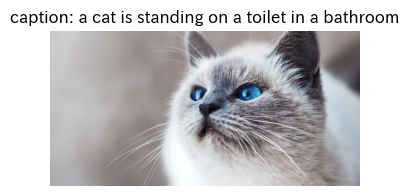

In [17]:
test_img_path = "test.jpg"
if not os.path.exists(test_img_path):
    raise FileNotFoundError(f"{test_img_path} が見つかりません")

img = Image.open(test_img_path).convert("RGB")
img_tensor = img_tf(img).unsqueeze(0).to(device)

caption = generate_caption(encoder, decoder, img_tensor)
print("caption:", caption)

plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.axis("off")
plt.title(f"caption: {caption}")
plt.show()